### **PROJECT: Customer Segmentation**
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
url = "https://raw.githubusercontent.com/Shahadat9886/Mall_Customers.csv/refs/heads/main/Thu%20H%C3%A0%20Tr%E1%BA%A7n%20-%20Mall_Customers.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print(df.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:
print(df.shape)

(200, 5)


In [7]:
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


#### **Select Features**
---

In [8]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [9]:
scale = StandardScaler()
X_scaled = scale.fit_transform(X)

#### **Elbow Method**
---

In [16]:
wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i,random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

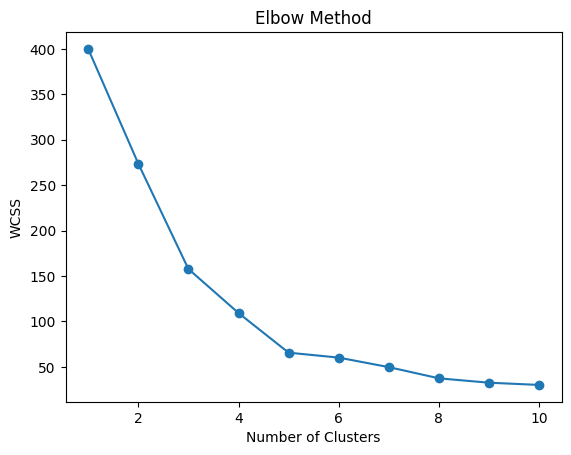

In [17]:
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

#### **Train Final Model**
---

In [18]:
kmeans = KMeans(n_clusters=5,random_state=42,n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [20]:
df['Clusters'] = clusters

In [22]:
df.sample(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Clusters
57,58,Male,69,44,46,0
129,130,Male,38,71,75,1
119,120,Female,50,67,57,0
182,183,Male,46,98,15,3
80,81,Male,57,54,51,0
35,36,Female,21,33,81,2
47,48,Female,27,40,47,0
77,78,Male,40,54,48,0
133,134,Female,31,72,71,1
90,91,Female,68,59,55,0


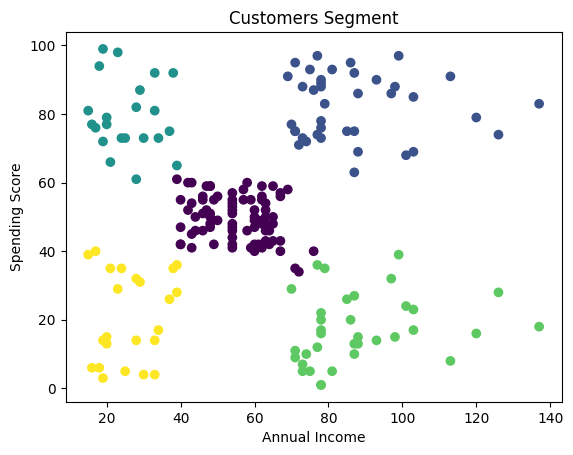

In [33]:

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['Clusters'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customers Segment")
plt.show()

In [34]:
print(silhouette_score(X_scaled,clusters))

0.5546571631111091
